In [ ]:
import marimo as mo
import jax.numpy as jnp
import jax.scipy as scp
import jax
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

## 1. Simulate Data

In [ ]:
key = jax.random.PRNGKey(42)

In [ ]:
def generate_data(n_samples: int, key: jax.Array) -> tuple[jnp.array, jnp.array]:
    w = jnp.array([0.5, -1.2, 3.0])
    b = 1.8
    sigma_y = 1.0

    key, subkey1, subkey2 = jax.random.split(key, 3)
    X = jax.random.uniform(key=subkey1, minval=-3, maxval=3, shape=(n_samples, 3))
    mu = X @ w + b
    y = jax.random.normal(key=subkey2, shape=(n_samples,)) * sigma_y + mu

    return X, y

X, y = generate_data(1000, key)

W0306 14:15:38.080365 2968984 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 2. Specify Model

In [ ]:
def log_likelihood(w: jnp.array, b: float, X: jnp.array, y: jnp.array) -> float:
    mu = X @ w + b
    return jnp.sum(scp.stats.norm.logpdf(y, loc=mu, scale=1.0))

def log_prior(w: jnp.array, b: float, sigma_w: float = 10.0, sigma_b: float = 10.0) -> float:
    lp_w = jnp.sum(scp.stats.norm.logpdf(w, loc=0, scale=sigma_w))
    lp_b = scp.stats.norm.logpdf(b, loc=0, scale=sigma_b)
    return lp_w + lp_b

def log_posterior(w: jnp.array, b: float, X: jnp.array, y: jnp.array) -> float:
    return log_likelihood(w, b, X, y) + log_prior(w, b)

## 3. Implement MCMC

In [ ]:
def mh_sample(
    X: jnp.array,
    y: jnp.array,
    key: jax.Array,
    n_samples: int = 10000,
    burn_in: int = 1000,
    thin: int = 5,
    n_chains: int = 4,
    step_size: float = 0.1,
) -> list[jnp.array]:
    chains = []

    for chain in range(n_chains):
        # Split key for this chain
        key, chain_key = jax.random.split(key)

        # Random starting location per chain
        chain_key, subkey1, subkey2 = jax.random.split(chain_key, 3)
        w = jax.random.normal(key=subkey1, shape=(3,))
        b = jax.random.normal(key=subkey2)
        log_p = log_posterior(w, b, X, y)

        samples = []

        for i in range(n_samples * thin + burn_in):
            # Propose: random walk with Gaussian perturbation
            chain_key, subkey1, subkey2, subkey3 = jax.random.split(chain_key, 4)
            w_prop = w + jax.random.normal(key=subkey1, shape=(3,)) * step_size
            b_prop = b + jax.random.normal(key=subkey2) * step_size

            log_p_prop = log_posterior(w_prop, b_prop, X, y)

            # Accept/reject in log space: log(u) < log_p_prop - log_p
            log_u = jnp.log(jax.random.uniform(key=subkey3))
            if log_u < log_p_prop - log_p:
                w, b = w_prop, b_prop
                log_p = log_p_prop

            # Collect after burn-in, respecting thinning
            if i >= burn_in and (i - burn_in) % thin == 0:
                samples.append(jnp.concatenate([w, jnp.array([b])]))

        chains.append(jnp.stack(samples))

    return chains

## 4. MCMC Diagnostics

In [ ]:
step_size = 0.05
chains = mh_sample(
    X=X,
    y=y,
    key=key,
    n_samples=5000,
    burn_in=2000,
    thin=5,
    n_chains=4,
    step_size=step_size,
)

In [ ]:
param_names = [r"$w_0$", r"$w_1$", r"$w_2$", r"$b$"]
true_params = [0.5, -1.2, 3.0, 1.8]
all_samples = np.concatenate([np.array(c) for c in chains], axis=0)

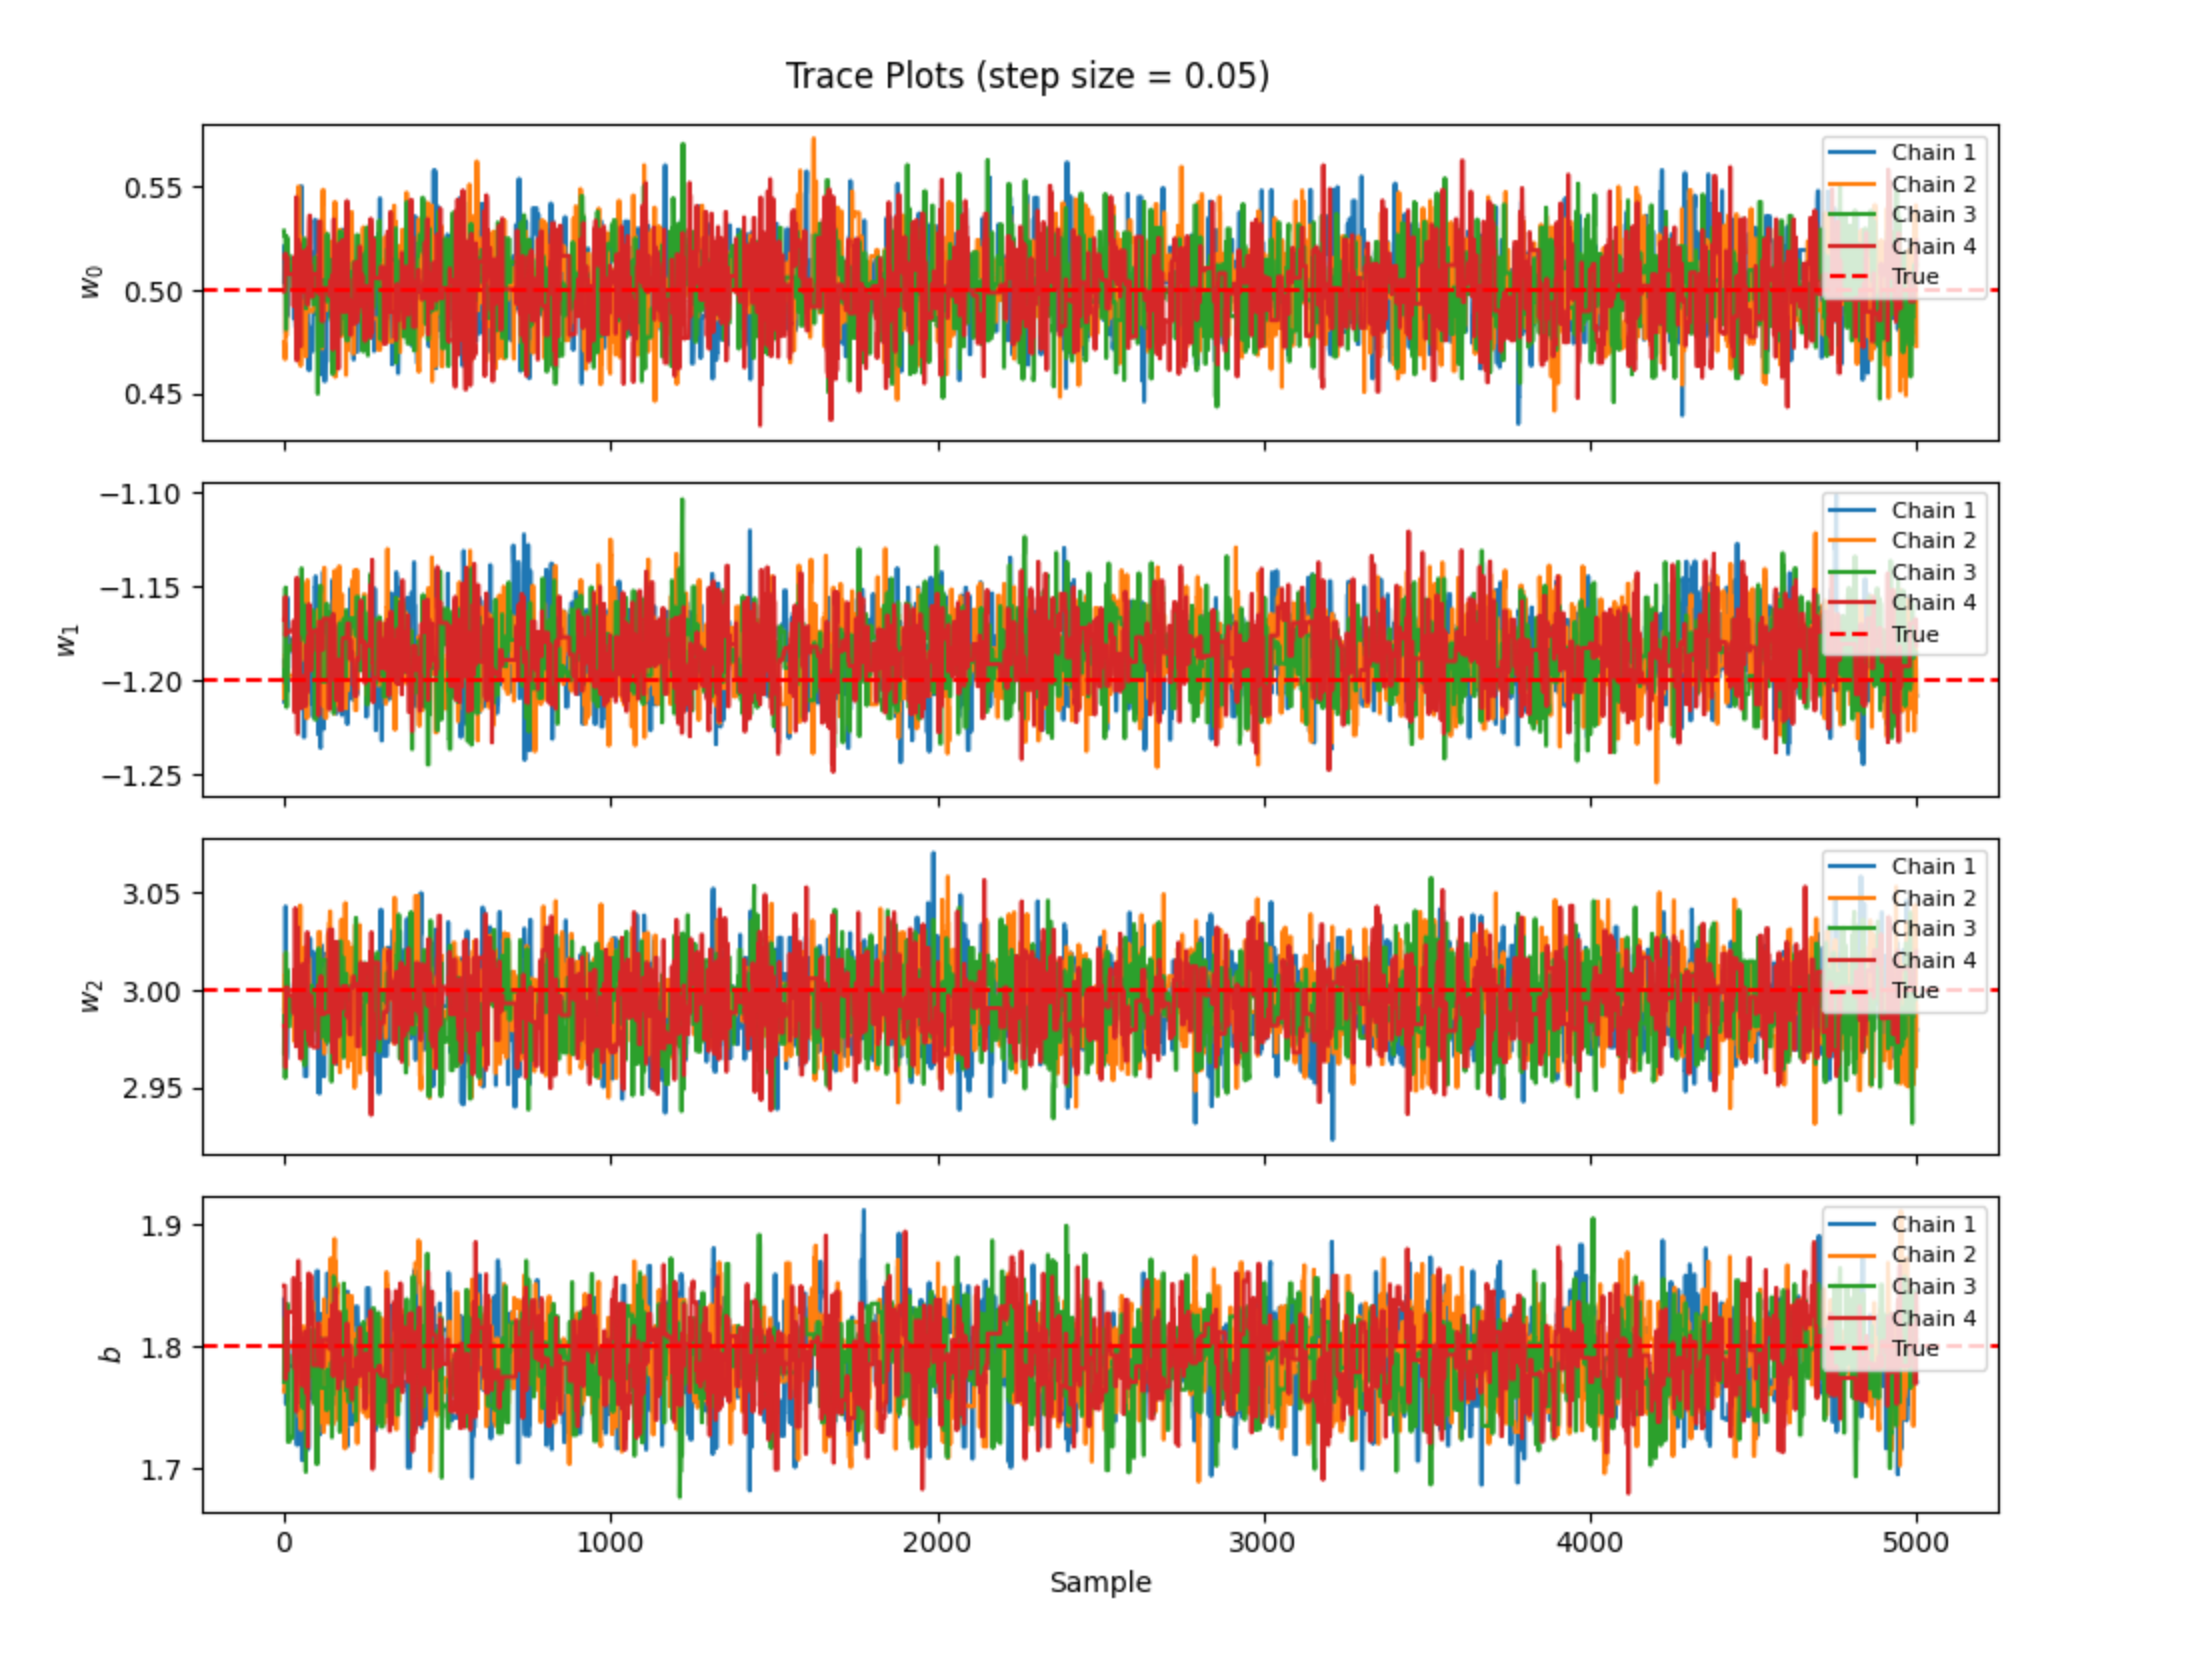

In [ ]:
def trace_plots():
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    # PLot a chart for each parameter
    for i, (ax, name, true_val) in enumerate(zip(axes, param_names, true_params)):

        # Plot each chain for the parameter
        for j, chain in enumerate(chains):
            ax.plot(np.array(chain[:, i]), label=f"Chain {j+1}")

        # True parameter
        ax.axhline(true_val, color="red", linestyle='--', label="True")
        ax.set_ylabel(name)
        ax.legend(loc="upper right", fontsize=8)

    # Format
    axes[-1].set_xlabel("Sample")
    fig.suptitle(f"Trace Plots (step size = {step_size})")
    plt.tight_layout()
    ax = mo.ui.matplotlib(plt.gca())
    return ax

trace_plots()

Note that all 4 chains converge around the true parameters and we observe proper mixing behaviors. I chose a step size of 0.05.

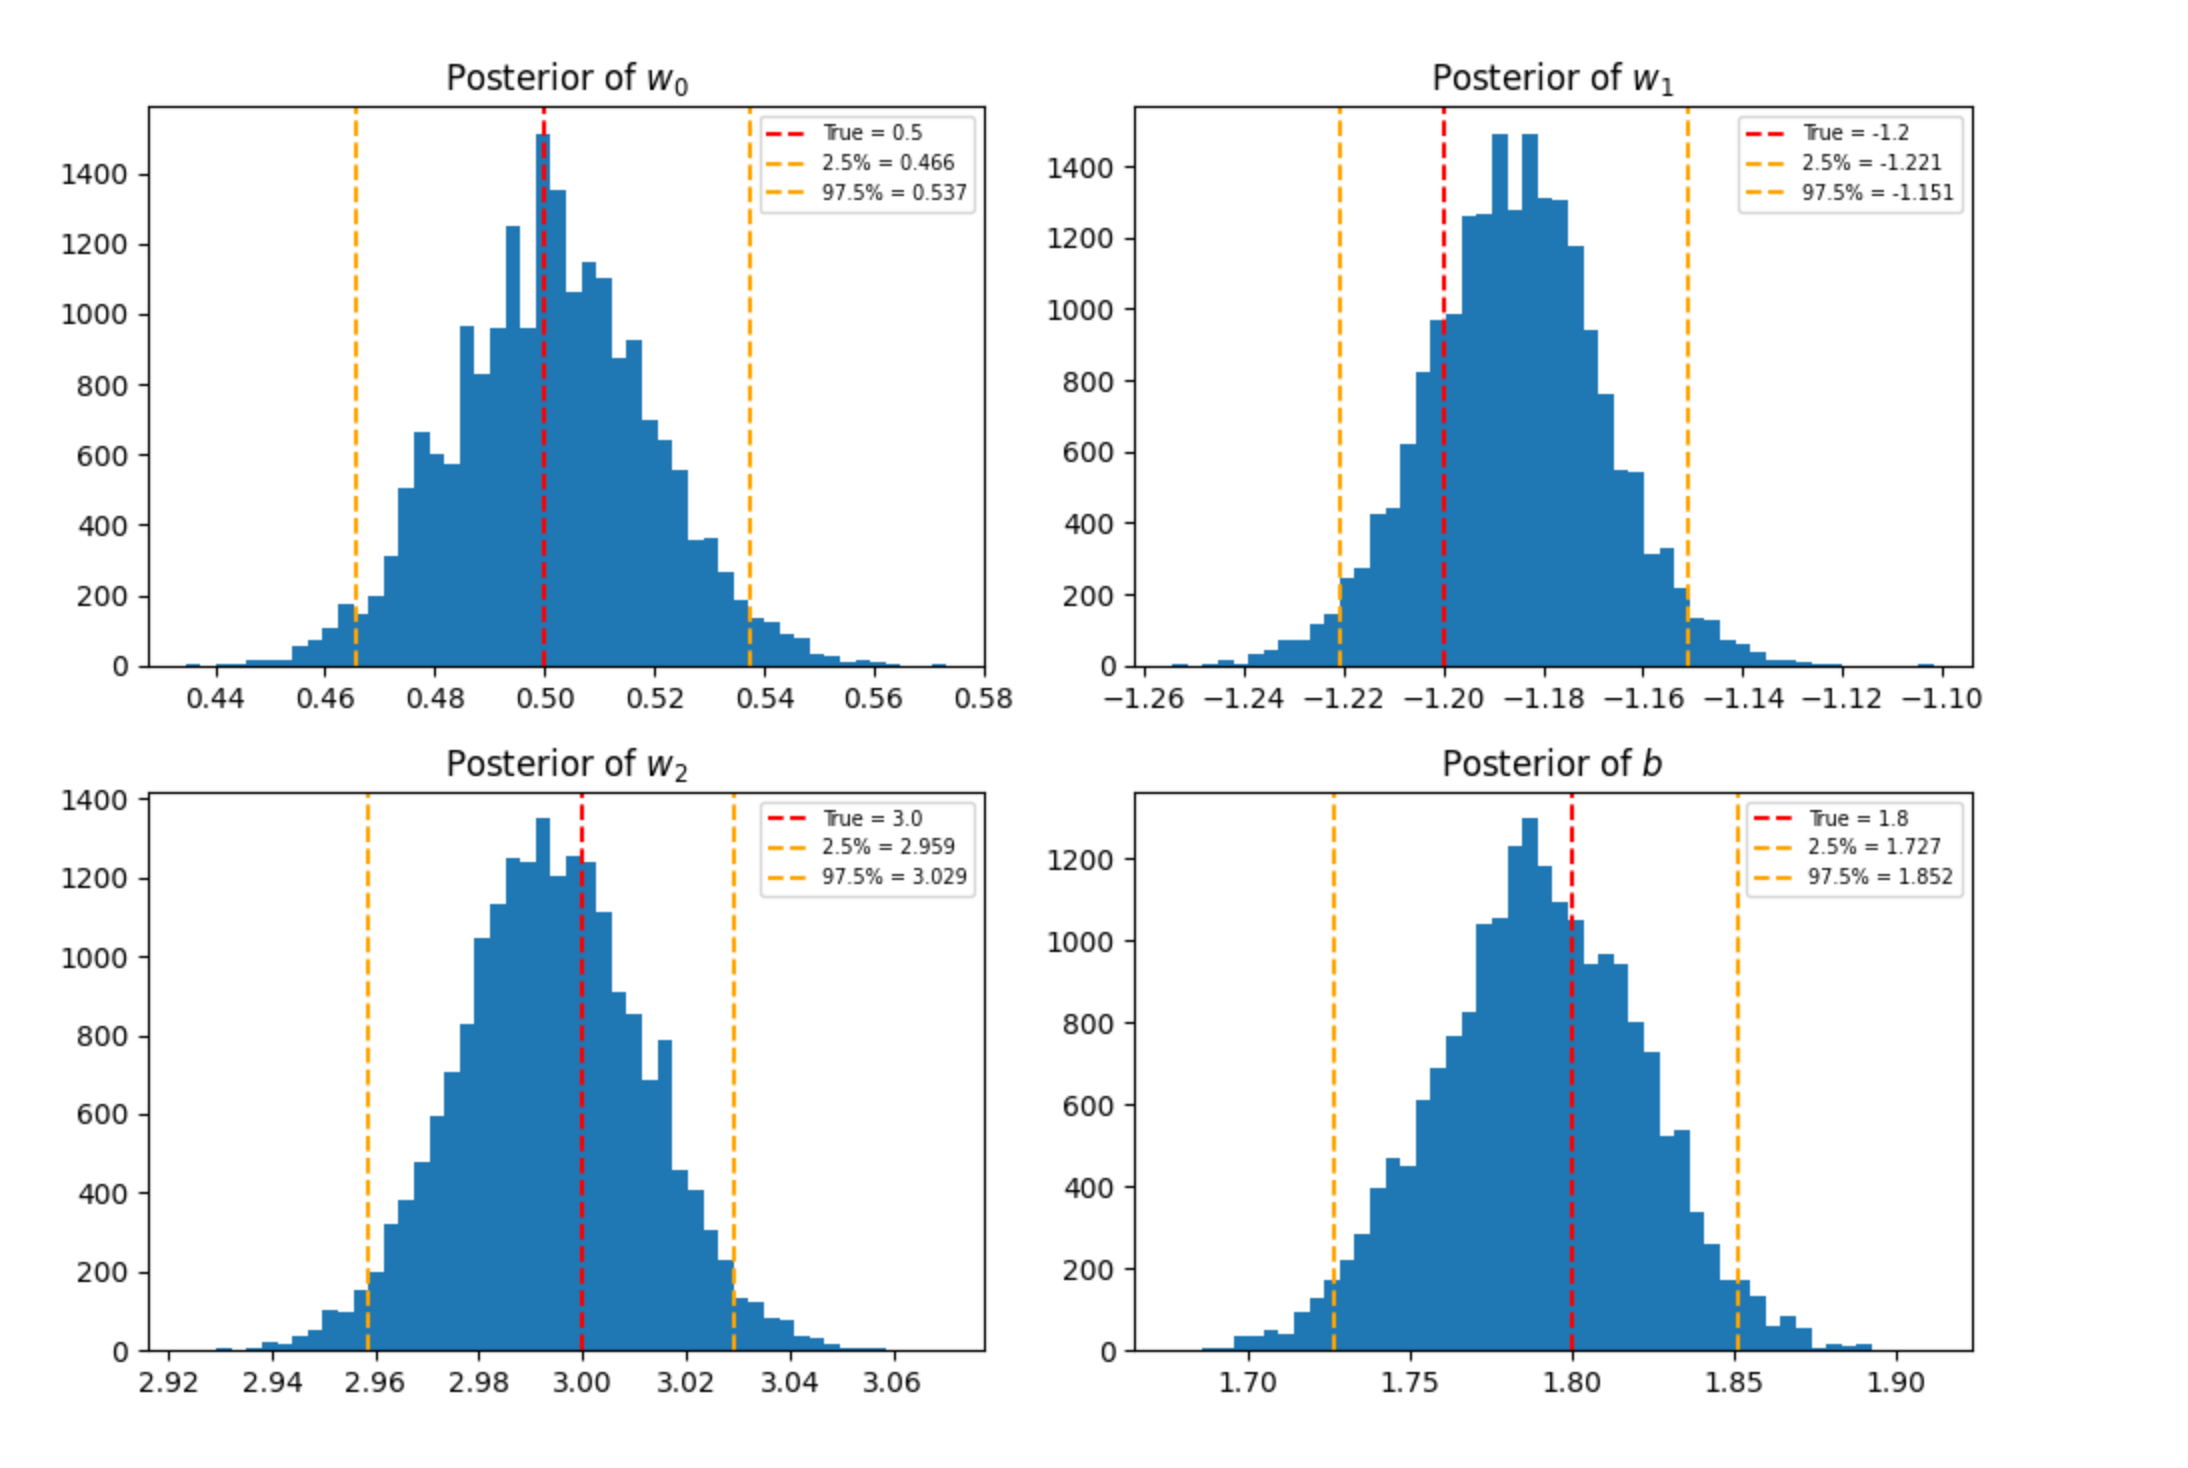

In [ ]:
def posterior_histograms():    
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # Plot each parameter's posterior histogram
    for i, (ax, name, true_val) in enumerate(zip(axes.flat, param_names, true_params)):
        # Get samples
        samples_i = all_samples[:, i]

        # Get credible intervals
        lo, hi = np.percentile(samples_i, [2.5, 97.5])

        # Plot each histogram
        ax.hist(samples_i, bins=50)
        ax.axvline(true_val, color="red", linestyle="--", label=f"True = {true_val}")
        ax.axvline(lo, color="orange", linestyle="--", label=f"2.5% = {lo:.3f}")
        ax.axvline(hi, color="orange", linestyle="--", label=f"97.5% = {hi:.3f}")
        ax.set_title(f"Posterior of {name}")
        ax.legend(fontsize=7)

    # Format
    plt.tight_layout()
    ax = mo.ui.matplotlib(plt.gca())
    return ax


posterior_histograms()

The true parameters fall neatly within our credible intervals.

## 5. PyMC Implementation

In [ ]:
def pymc_mh_sample(
    X: jnp.array,
    y: jnp.array,
    n_samples: int = 10000,
    n_chains: int = 4,
) -> list[jnp.array]:
    X_np = np.array(X)
    y_np = np.array(y)

    with pm.Model() as linear_model:
        # Priors
        w = pm.Normal("w", mu=0, sigma=10, shape=3)
        b = pm.Normal("b", mu=0, sigma=10)
        sigma_y = pm.HalfNormal("sigma_y", sigma=5)

        # Likelihood
        mu = X_np @ w + b
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_y, observed=y_np)

        # Sample (NUTS by default)
        trace = pm.sample(n_samples, tune=1000, chains=n_chains)

    return trace

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, b, sigma_y]
/Users/andrew/.local/share/uv/python/cpython-3.14.0-macos-aarch64-none/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 2 seconds.


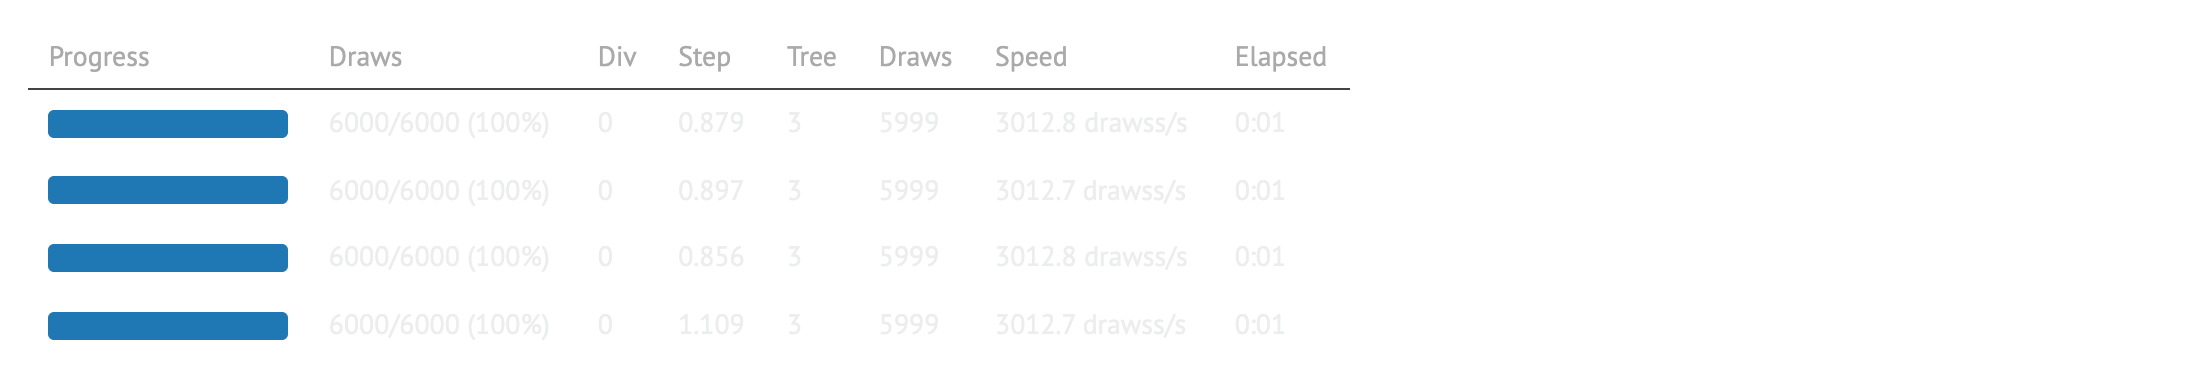

In [ ]:
trace = pymc_mh_sample(
    X=X,
    y=y,
    n_samples=5000,
    n_chains=4,
)

In [ ]:
sigma_y_true = 1.0
all_true = true_params + [sigma_y_true]
all_names = param_names + [r"$\sigma_y$"]

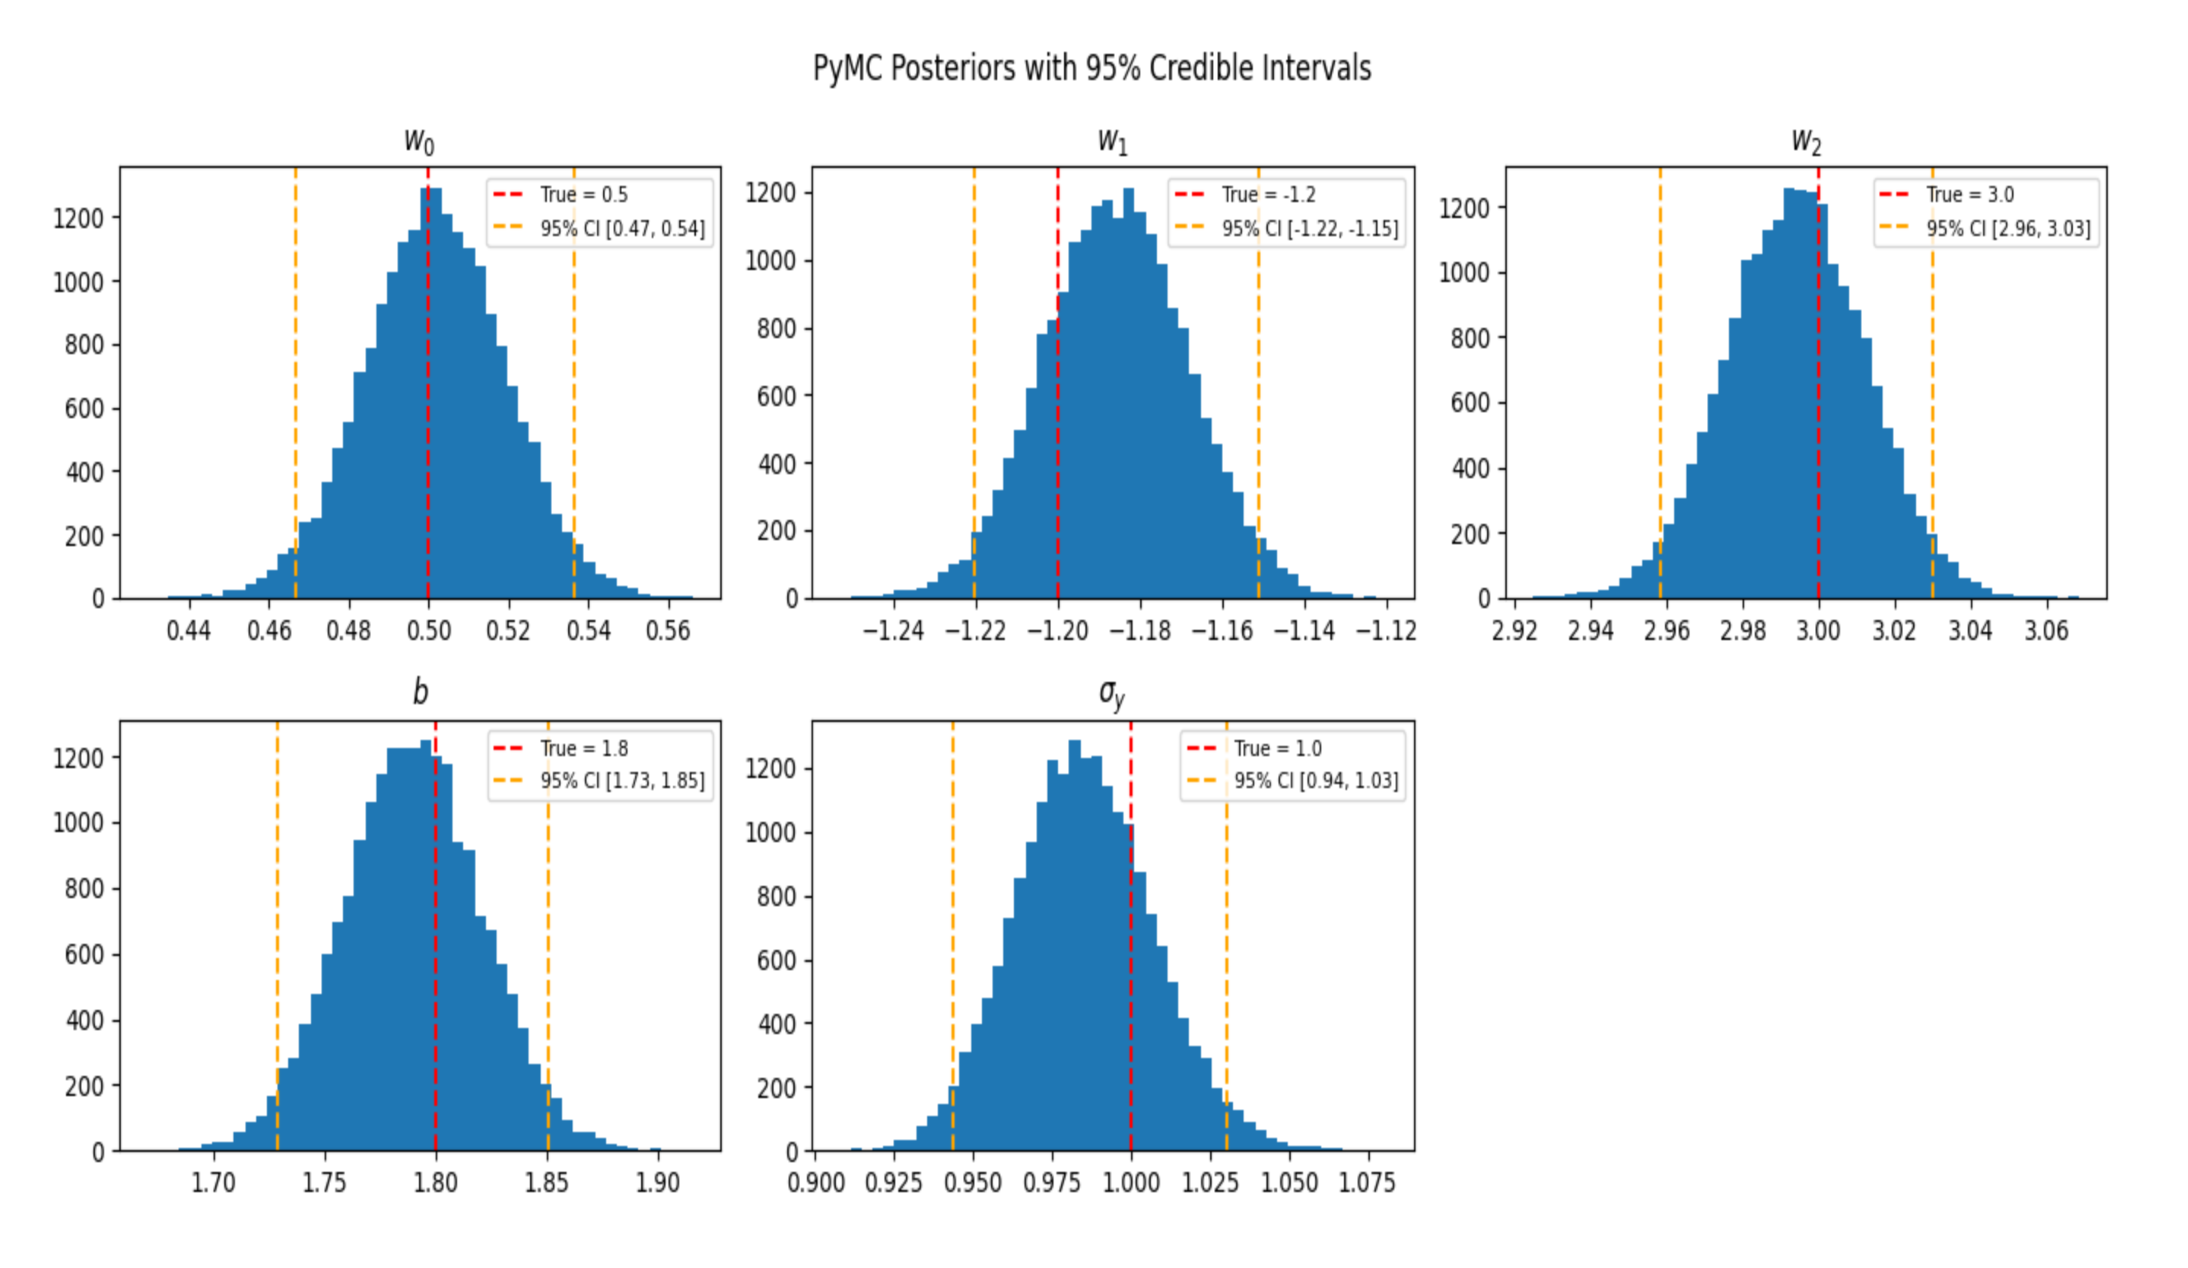

In [ ]:
def pymc_posterior_histograms():
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    axes = axes.flatten()

    param_map = [("w", 0), ("w", 1), ("w", 2), ("b", None), ("sigma_y", None)]

    for i, (name, idx) in enumerate(param_map):
        ax = axes[i]
        if idx is not None:
            samples = trace.posterior[name].values[:, :, idx].flatten()
        else:
            samples = trace.posterior[name].values.flatten()

        ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

        ax.hist(samples, bins=50)
        ax.axvline(all_true[i], color="red", linestyle="--", label=f"True = {all_true[i]}")
        ax.axvline(ci_low, color="orange", linestyle="--", label=f"95% CI [{ci_low:.2f}, {ci_high:.2f}]")
        ax.axvline(ci_high, color="orange", linestyle="--")
        ax.set_title(all_names[i])
        ax.legend(fontsize=8)

    axes[-1].set_visible(False)
    plt.suptitle("PyMC Posteriors with 95% Credible Intervals")
    plt.tight_layout()
    ax = mo.ui.matplotlib(plt.gca())
    return ax

pymc_posterior_histograms()

The credible intervals and posterior distributions follow very closely between the custom and PyMC implementations.